In [38]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

# Plotting Training vs Validation Learning Curve

In [39]:
epochs = [1, 2, 3, 4, 5]
train_loss = [0.9, 0.7, 0.5, 0.3, 0.2]
val_loss = [0.95, 0.8, 0.75, 0.78, 0.85]

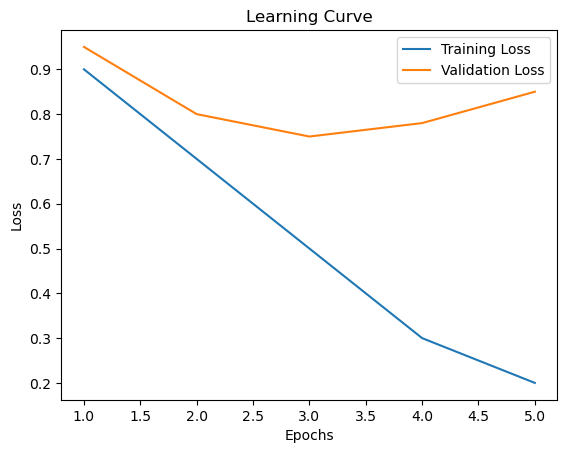

In [40]:
plt.plot(epochs, train_loss, label="Training Loss")
plt.plot(epochs, val_loss, label="Validation Loss")

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Learning Curve")
plt.legend()
plt.show()

# TensorFlow: Training vs Validation Loss and Accuracy Curves

In [41]:
# Create random input features
x = np.random.rand(1000, 10)

# Create binary labels based on a simple rule
y = (np.sum(x, axis=1) > 5).astype(int)

# Building Neural Network Model
model = tf.keras.Sequential([
    tf.keras.Input(shape=(10,)),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

# Compiling Model
model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

# Train model
history = model.fit(x, y, epochs=20, batch_size=32, validation_split=0.2)


Epoch 1/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step - accuracy: 0.5638 - loss: 0.6797 - val_accuracy: 0.5450 - val_loss: 0.6643
Epoch 2/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5663 - loss: 0.6606 - val_accuracy: 0.5850 - val_loss: 0.6478
Epoch 3/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6650 - loss: 0.6428 - val_accuracy: 0.6800 - val_loss: 0.6275
Epoch 4/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7075 - loss: 0.6185 - val_accuracy: 0.7150 - val_loss: 0.6037
Epoch 5/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7563 - loss: 0.5850 - val_accuracy: 0.7900 - val_loss: 0.5781
Epoch 6/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7850 - loss: 0.5512 - val_accuracy: 0.7700 - val_loss: 0.5347
Epoch 7/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8087 - loss: 0.5082 - val_accuracy: 0.7100 - val_loss: 0.5118
Epoch 8/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8388 - loss: 0.4693 - val_accuracy: 0.8400 - val_

In [42]:
print(history.history.keys())

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


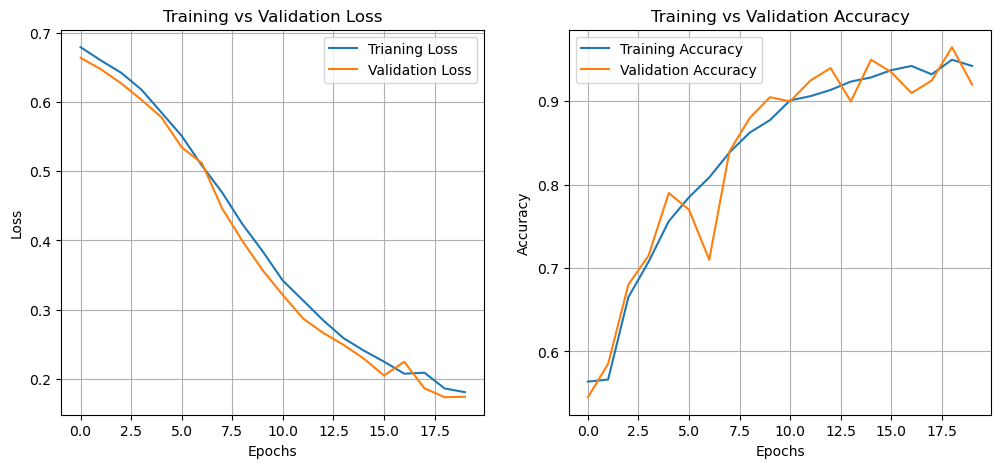

In [43]:
# Extracting Learning Curves
train_loss = history.history["loss"]
val_loss = history.history["val_loss"]
train_acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]

# Plotting
plt.figure(figsize=(12, 5))

# Plotting Loss Curve
plt.subplot(1, 2, 1)
plt.plot(train_loss, label="Trianing Loss")
plt.plot(val_loss, label="Validation Loss")
plt.title('Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Plotting Accuracy Curve
plt.subplot(1, 2, 2)
plt.plot(train_acc, label="Training Accuracy")
plt.plot(val_acc, label="Validation Accuracy")
plt.title("Training vs Validation Accuracy")
plt.xlabel('Epochs')
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.show()

# K-Fold Cross Validation

### Using sklearn

In [44]:
from sklearn.model_selection import KFold
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import load_iris
from sklearn.metrics import accuracy_score

data = load_iris()
X, y = data.data, data.target

kf = KFold(n_splits=5) # NO shuffling, Uses original order of data

model = LogisticRegression(max_iter=200)

scores = []

for train_index, test_index in kf.split(X):
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

    model.fit(X_train, y_train)
    predictions = model.predict(X_test)

    scores.append(accuracy_score(y_test, predictions))

print("Cross Valudation Scores: ", scores)
print("Average Score: ", sum(scores) / len(scores))

Cross Valudation Scores:  [1.0, 1.0, 0.8666666666666667, 0.9333333333333333, 0.8333333333333334]
Average Score:  0.9266666666666667


### Using Tensorflow

In [ ]:
import numpy as np
import tensorflow as tf
from sklearn.model_selection import KFold
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler

# --- 1. PREPROCESSING PIPELINE ---
data = load_iris()
X_base, y_base = data.data, data.target

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_base)

kf = KFold(n_splits=5, shuffle=True, random_state=42)

In [ ]:
# ==========================================================
# LOOP 1: BASELINE TRAINING (Fixed Epochs, No Early Stopping)
# ==========================================================
print("=== STARTING LOOP 1: BASELINE ===")
scores_baseline = []

for train_index, test_index in kf.split(X_scaled):
    X_train, X_test = X_scaled[train_index], X_scaled[test_index]
    y_train, y_test = y_base[train_index], y_base[test_index]

    model_base = tf.keras.Sequential([
        tf.keras.Input(shape=(X_scaled.shape[1],)),
        tf.keras.layers.Dense(16, activation="relu"),
        tf.keras.layers.Dense(8, activation="relu"),
        tf.keras.layers.Dense(3, activation="softmax")
    ])
    
    model_base.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    
    # Train completely for 30 epochs without restrictions
    model_base.fit(X_train, y_train, epochs=30, batch_size=16, validation_split=0.2, verbose=0)
    
    test_loss, test_acc = model_base.evaluate(X_test, y_test, verbose=0)
    scores_baseline.append(test_acc)

=== STARTING LOOP 1: BASELINE ===


In [ ]:
# ==========================================================
# LOOP 2: REGULARIZED TRAINING (With Early Stopping Active)
# ==========================================================

# Define early stopping configuration
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', 
    patience=3, 
    restore_best_weights=True
)

print("\n=== STARTING LOOP 2: WITH EARLY STOPPING ===")
scores_early_stop = []

for train_index, test_index in kf.split(X_scaled):
    X_train, X_test = X_scaled[train_index], X_scaled[test_index]
    y_train, y_test = y_base[train_index], y_base[test_index]

    model_exp = tf.keras.Sequential([
        tf.keras.Input(shape=(X_scaled.shape[1],)),
        tf.keras.layers.Dense(16, activation="relu"),
        tf.keras.layers.Dense(8, activation="relu"),
        tf.keras.layers.Dense(3, activation="softmax")
    ])
    
    model_exp.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    
    # Train up to 50 epochs, letting early_stop kill execution if validation loss plateaus
    model_exp.fit(X_train, y_train, epochs=50, batch_size=16, validation_split=0.2, callbacks=[early_stop], verbose=0)
    
    _, test_acc = model_exp.evaluate(X_test, y_test, verbose=0)
    scores_early_stop.append(test_acc)


=== STARTING LOOP 2: WITH EARLY STOPPING ===


In [50]:
# ==========================================================
# FINAL ACCURACY SCORE COMPARISON TABLE
# ==========================================================
print("\n=== PERFORMANCE REPORT ===")
print(f"Baseline Loop Folds:     {[round(s, 3) for s in scores_baseline]}")
print(f"Baseline Average:        {round(np.mean(scores_baseline), 4)}")
print("-" * 50)
print(f"Early Stop Loop Folds:   {[round(s, 3) for s in scores_early_stop]}")
print(f"Early Stop Average:      {round(np.mean(scores_early_stop), 4)}")


=== PERFORMANCE REPORT ===
Baseline Loop Folds:     [0.7, 0.9, 0.867, 0.9, 0.9]
Baseline Average:        0.8533
--------------------------------------------------
Early Stop Loop Folds:   [0.933, 0.667, 0.0, 0.5, 0.533]
Early Stop Average:      0.5267


[========================== TOTAL ORIGINAL DATASET ==========================]
                                             │
               ┌─────────────────────────────┴─────────────────────────────┐
               ▼                                                           ▼
┌───────────────────────────────────────┐                   ┌───────────────────────────┐
│           TRAINING DATASET            │                   │       TEST DATASET        │
│               (X_train)               │                   │         (X_test)          │
└───────────────────┬───────────────────┘                   └─────────────┬─────────────┘
                    │                                                     │
     ┌──────────────┴──────────────┐                                      │
     ▼                             ▼                                      ▼
┌─────────────────────────┐   ┌─────────────────────────┐   ┌───────────────────────────┐
│     Actual Training     │   │    Validation Split     │   │    Ultimate Final Exam    │
│        Sub-slice        │   │       (val_loss)        │   │         (X_test)          │
│          (90%)          │   │          (10%)          │   │                           │
├─────────────────────────┼─────────────────────────────┼───────────────────────────┤
│ Model calculates math   │ • Used by EarlyStopping.    │ • Kept in a locked vault  │
│ gradients and updates   │ • Dictates when to halt.    │   until training finishes.│
│ internal weights.       │ • NO weights are updated.   │ • Provides your true, unbiased│
│                         │                             │   generalization score.   │
└─────────────────────────┘   └─────────────────────────┘   └───────────────────────────┘

# Added K-Fold with Early Stopping and Dropout 

In [53]:
data = load_iris()
X, y = data.data, data.target

kf = KFold(n_splits=5, shuffle=True, random_state=42)
scores = []

for train_idx, test_idx in kf.split(X):
    
    X_train_raw, X_test_raw = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    # scale INSIDE fold (no leakage)
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train_raw)
    X_test = scaler.transform(X_test_raw)

    model = tf.keras.Sequential([
        tf.keras.layers.Dense(64, activation='relu', input_shape=(4,)),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(32, activation='relu'),
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.Dense(3, activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    early_stop = tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=4,
        restore_best_weights=True
    )

    history = model.fit(
        X_train, y_train,
        epochs=40,
        validation_split=0.1,
        callbacks=[early_stop],
        verbose=0
    )

    test_loss, test_accuracy = model.evaluate(X_test, y_test)
    scores.append(test_accuracy)

print("Cross Valudation Scores: ", scores)
print("Average Score: ", sum(scores) / len(scores))

/home/luc/miniconda3/envs/jupyter/lib/python3.13/site-packages/keras/src/layers/core/dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 685ms/step - accuracy: 0.9667 - loss: 0.1712


/home/luc/miniconda3/envs/jupyter/lib/python3.13/site-packages/keras/src/layers/core/dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 688ms/step - accuracy: 0.9333 - loss: 0.2154


/home/luc/miniconda3/envs/jupyter/lib/python3.13/site-packages/keras/src/layers/core/dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 658ms/step - accuracy: 0.9333 - loss: 0.1949


/home/luc/miniconda3/envs/jupyter/lib/python3.13/site-packages/keras/src/layers/core/dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 696ms/step - accuracy: 0.8333 - loss: 0.3707


/home/luc/miniconda3/envs/jupyter/lib/python3.13/site-packages/keras/src/layers/core/dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 606ms/step - accuracy: 0.8333 - loss: 0.3900
Cross Valudation Scores:  [0.9666666388511658, 0.9333333373069763, 0.9333333373069763, 0.8333333134651184, 0.8333333134651184]
Average Score:  0.899999988079071
